<a href="https://colab.research.google.com/github/jhaymhee111-bit/My-python-assignments/blob/main/telco_churn_full_workflow.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Telco Customer Churn Prediction

## Complete Supervised Learning Workflow

This notebook follows the complete workflow from defining the problem to saving the final pipeline.

In [ ]:
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, average_precision_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay, PrecisionRecallDisplay
RANDOM_STATE=42

## 1. DEFINE PROBLEM

We want to identify telecommunications customers who are at higher risk of leaving the service. The target is `Churn`: `Yes` means the customer churned and `No` means the customer stayed. This is a binary supervised classification problem. The output is a risk estimate for retention support, not a guarantee that a customer will leave.

## 2. LOAD DATA

In [ ]:
DATA_URL="https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"
df=pd.read_csv(DATA_URL)
print("Shape:",df.shape)
df.head()

Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 3. UNDERSTAND DATA

Inspect shape, columns, types, summaries, and representative rows before modeling.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [ ]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customerID,7043,7043,3186-AJIEK,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,7043,2,Male,3555,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SeniorCitizen,7043.0,NaN,NaN,NaN,0.162147,0.368612,0.0,0.0,0.0,0.0,1.0
Partner,7043,2,No,3641,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Dependents,7043,2,No,4933,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tenure,7043.0,NaN,NaN,NaN,32.371149,24.559481,0.0,9.0,29.0,55.0,72.0
PhoneService,7043,2,Yes,6361,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MultipleLines,7043,3,No,3390,NaN,NaN,NaN,NaN,NaN,NaN,NaN
InternetService,7043,3,Fiber optic,3096,NaN,NaN,NaN,NaN,NaN,NaN,NaN
OnlineSecurity,7043,3,No,3498,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 4. EXPLORE TARGET

Churn
No     5174
Yes    1869
Name: count, dtype: int64
Churn
No     73.46
Yes    26.54
Name: proportion, dtype: float64


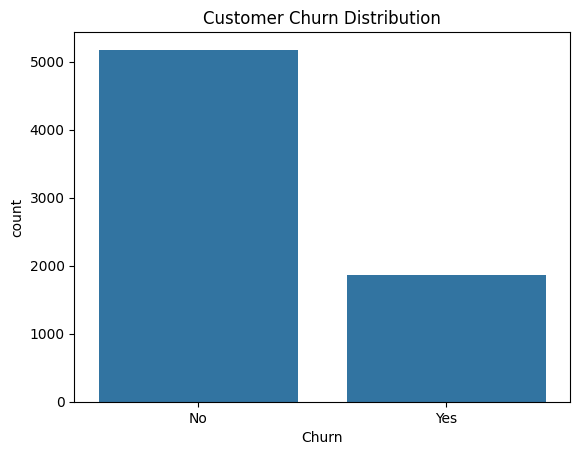

In [ ]:
print(df["Churn"].value_counts())
print((df["Churn"].value_counts(normalize=True)*100).round(2))
sns.countplot(data=df,x="Churn"); plt.title("Customer Churn Distribution"); plt.show()

## 5. EXPLORE FEATURES

Numeric: ['SeniorCitizen', 'tenure', 'MonthlyCharges']
Categorical: ['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'TotalCharges', 'Churn']


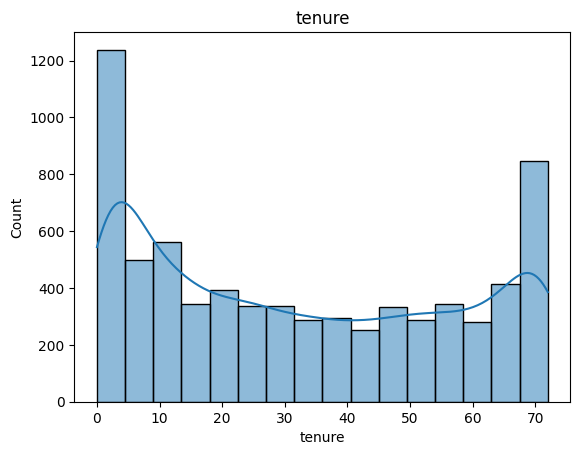

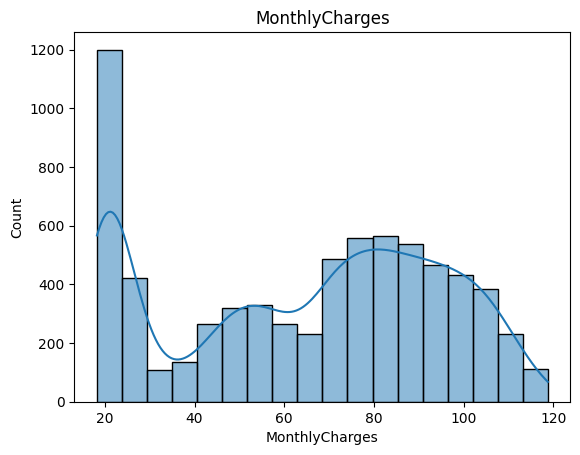

In [ ]:
print("Numeric:",df.select_dtypes(include=np.number).columns.tolist())
print("Categorical:",df.select_dtypes(include="object").columns.tolist())
for col in ["tenure","MonthlyCharges"]:
    sns.histplot(data=df,x=col,kde=True); plt.title(col); plt.show()

## 6. CHECK MISSING VALUES

`TotalCharges` contains blank strings in the raw dataset, so it needs numeric conversion before missing-value handling.

In [ ]:
check=df.copy()
check["TotalCharges"]=pd.to_numeric(check["TotalCharges"],errors="coerce")
print(check.isna().sum().sort_values(ascending=False).head(15))

TotalCharges        11
gender               0
SeniorCitizen        0
Partner              0
customerID           0
Dependents           0
tenure               0
MultipleLines        0
PhoneService         0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
InternetService      0
TechSupport          0
StreamingTV          0
dtype: int64


## 7. CHECK SUSPICIOUS VALUES / OUTLIERS

Outliers are investigated rather than automatically deleted. A high charge can be a legitimate customer value.

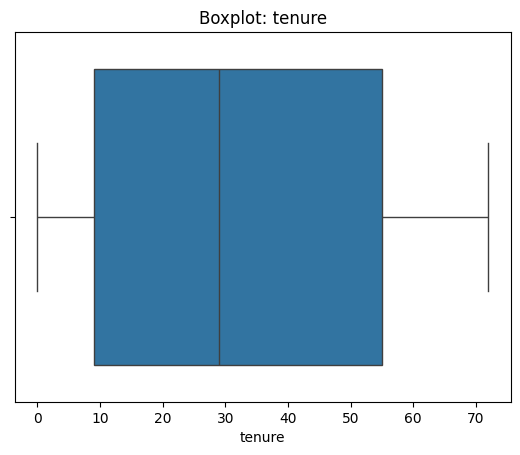

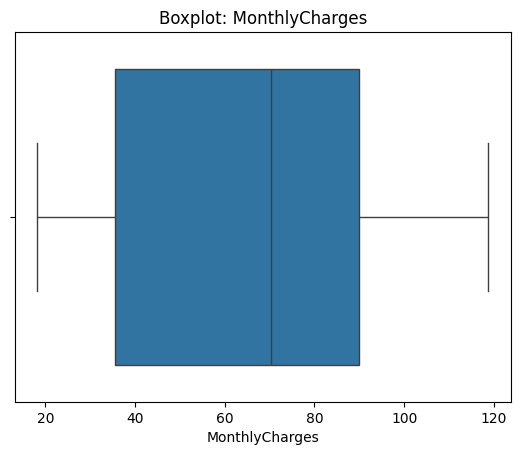

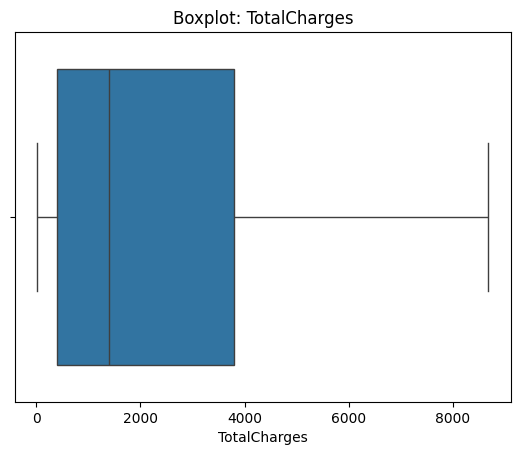

In [ ]:
for col in ["tenure","MonthlyCharges","TotalCharges"]:
    vals=pd.to_numeric(check[col],errors="coerce")
    sns.boxplot(x=vals); plt.title(f"Boxplot: {col}"); plt.show()

## 8. EDA / RELATIONSHIPS

Look at how important service and contract variables relate to churn. These are relationships, not causal conclusions.

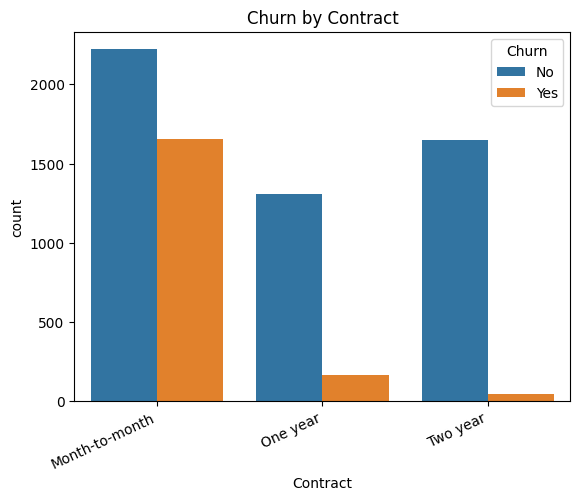

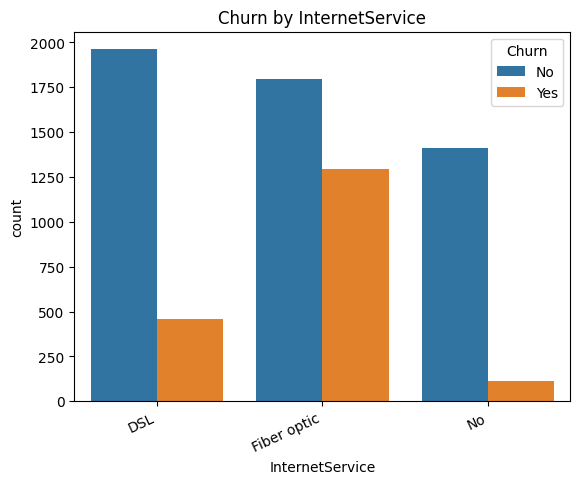

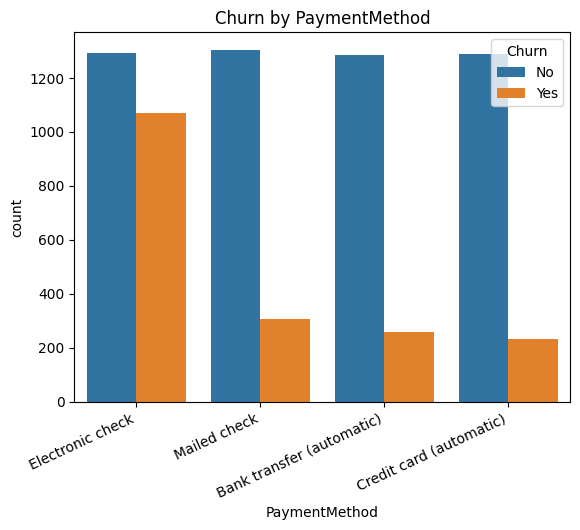

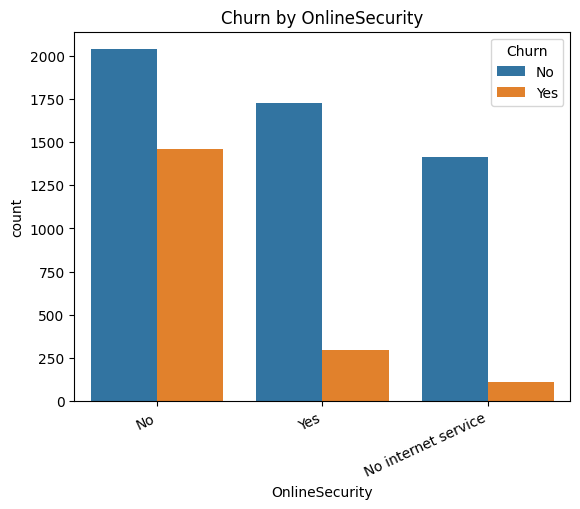

In [ ]:
for col in ["Contract","InternetService","PaymentMethod","OnlineSecurity"]:
    sns.countplot(data=df,x=col,hue="Churn"); plt.xticks(rotation=25,ha="right"); plt.title(f"Churn by {col}"); plt.show()

## 9. SEPARATE X AND y

In [ ]:
work=df.copy()
work["TotalCharges"]=pd.to_numeric(work["TotalCharges"],errors="coerce")
work["SeniorCitizen"]=work["SeniorCitizen"].map({0:"No",1:"Yes"})
work["AverageMonthlySpend"]=np.where(work["tenure"]>0,work["TotalCharges"]/work["tenure"],work["MonthlyCharges"])
X=work.drop(columns=["Churn","customerID"])
y=work["Churn"].map({"No":0,"Yes":1}).astype(int)
print(X.shape,y.shape)

(7043, 20) (7043,)


## 10. TRAIN / TEST SPLIT

Use a stratified split. The test set is held back and will not be used to select the model.

In [ ]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=.20,random_state=RANDOM_STATE,stratify=y)
print(len(X_train),len(X_test),y_train.mean(),y_test.mean())

5634 1409 0.2653532126375577 0.2654364797728886


## 11. PREPROCESSING

Numeric columns receive median imputation and scaling. Categorical columns receive most-frequent imputation and one-hot encoding. The preprocessing is kept inside the pipeline so it is learned only from the appropriate training folds.

In [ ]:
def build_preprocessor(X):
    cat=X.select_dtypes(include=["object"]).columns.tolist()
    num=X.select_dtypes(include=["number"]).columns.tolist()
    return ColumnTransformer([
        ("num",Pipeline([("imputer",SimpleImputer(strategy="median")),("scaler",StandardScaler())]),num),
        ("cat",Pipeline([("imputer",SimpleImputer(strategy="most_frequent")),("onehot",OneHotEncoder(handle_unknown="ignore"))]),cat),
    ])

def build_pipeline(model):
    return Pipeline([("preprocessor",build_preprocessor(X_train)),("model",model)])

## 12. BASELINE

A majority-class baseline gives us a simple reference point.

In [ ]:
baseline=build_pipeline(DummyClassifier(strategy="most_frequent"))
baseline.fit(X_train,y_train)
p=baseline.predict(X_test)
print("Baseline accuracy:",accuracy_score(y_test,p))
print("Baseline F1:",f1_score(y_test,p,zero_division=0))

Baseline accuracy: 0.7345635202271115
Baseline F1: 0.0


## 13. CROSS-VALIDATION

In [ ]:
cv=StratifiedKFold(n_splits=5,shuffle=True,random_state=RANDOM_STATE)
scoring=["accuracy","precision","recall","f1","roc_auc"]

## 14. HANDLE IMBALANCE

Churn is not evenly distributed. We use `class_weight="balanced"` for the candidate classifiers and report precision, recall, F1, ROC-AUC, and PR-AUC rather than relying on accuracy alone.

## 15. CANDIDATE MODELS

In [ ]:
candidates={
"Logistic Regression":LogisticRegression(max_iter=2000,class_weight="balanced",random_state=RANDOM_STATE),
"Random Forest":RandomForestClassifier(n_estimators=300,class_weight="balanced",min_samples_leaf=2,random_state=RANDOM_STATE,n_jobs=-1)
}

## 16. MODEL COMPARISON

In [ ]:
rows=[]
for name,model in candidates.items():
    pipe=build_pipeline(model)
    s=cross_validate(pipe,X_train,y_train,cv=cv,scoring=scoring)
    rows.append({"model":name,**{m:s["test_"+m].mean() for m in scoring}})
comparison=pd.DataFrame(rows).sort_values("f1",ascending=False)
comparison

,model,accuracy,precision,recall,f1,roc_auc
0,Logistic Regression,0.749735,0.518523,0.799331,0.628850,0.845463
1,Random Forest,0.790027,0.598731,0.634114,0.615621,0.837972


## 17. HYPERPARAMETER TUNING

Tune the Random Forest using only the training set and cross-validation. The held-out test set remains closed.

In [ ]:
rf=build_pipeline(RandomForestClassifier(class_weight="balanced",random_state=RANDOM_STATE,n_jobs=-1))
param_grid={"model__n_estimators":[200,400],"model__max_depth":[None,10,20],"model__min_samples_leaf":[1,2,5],"model__max_features":["sqrt","log2"]}
search=GridSearchCV(rf,param_grid,scoring="f1",cv=cv,n_jobs=-1,verbose=1)
search.fit(X_train,y_train)
print(search.best_params_)
print(search.best_score_)

Fitting 5 folds for each of 36 candidates, totalling 180 fits
{'model__max_depth': 10, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 5, 'model__n_estimators': 400}
0.633471851516437


## 18. FINAL MODEL

In [ ]:
final_model=search.best_estimator_

## 19. OPEN TEST SET

Only now do we use the held-out test set for the final evaluation.

In [ ]:
test_pred=final_model.predict(X_test)
test_prob=final_model.predict_proba(X_test)[:,1]

## 20. FINAL TEST EVALUATION

In [ ]:
metrics={"Accuracy":accuracy_score(y_test,test_pred),"Precision":precision_score(y_test,test_pred,zero_division=0),"Recall":recall_score(y_test,test_pred,zero_division=0),"F1":f1_score(y_test,test_pred,zero_division=0),"ROC-AUC":roc_auc_score(y_test,test_prob),"PR-AUC":average_precision_score(y_test,test_prob)}
pd.Series(metrics).round(4)

,0
Accuracy,0.7651
Precision,0.5414
Recall,0.7513
F1,0.6293
ROC-AUC,0.8421
PR-AUC,0.6519


In [ ]:
print(classification_report(y_test,test_pred,target_names=["No Churn","Churn"],zero_division=0))
print(confusion_matrix(y_test,test_pred))

              precision    recall  f1-score   support

    No Churn       0.90      0.77      0.83      1035
       Churn       0.54      0.75      0.63       374

    accuracy                           0.77      1409
   macro avg       0.72      0.76      0.73      1409
weighted avg       0.80      0.77      0.78      1409

[[797 238]
 [ 93 281]]


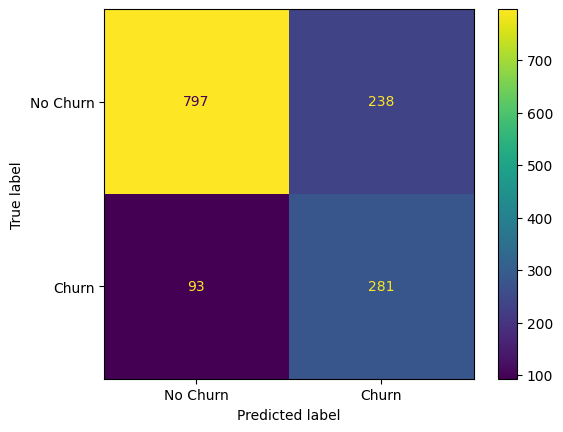

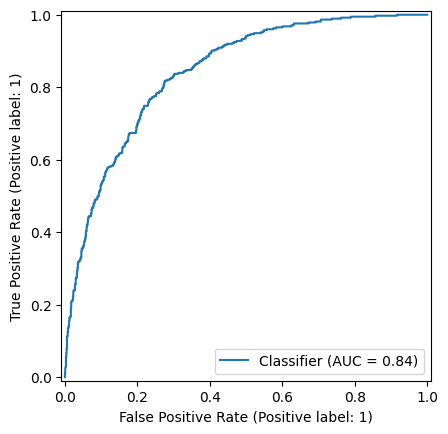

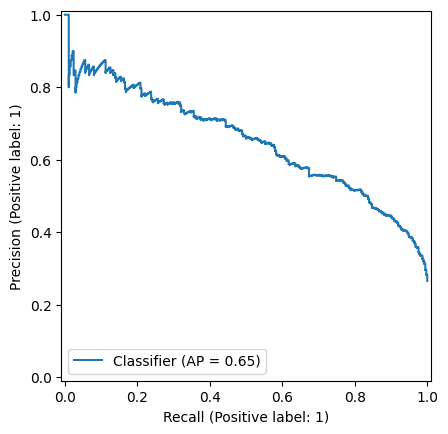

In [ ]:
ConfusionMatrixDisplay.from_predictions(y_test,test_pred,display_labels=["No Churn","Churn"]); plt.show()
RocCurveDisplay.from_predictions(y_test,test_prob); plt.show()
PrecisionRecallDisplay.from_predictions(y_test,test_prob); plt.show()

## 21. MODEL INTERPRETATION

Random Forest feature importance tells us which transformed features were useful to the fitted model. It does not prove causation.

In [ ]:
prep=final_model.named_steps["preprocessor"]
rf=final_model.named_steps["model"]
names=prep.get_feature_names_out()
importance=pd.DataFrame({"feature":names,"importance":rf.feature_importances_}).sort_values("importance",ascending=False)
importance.head(20)

,feature,importance
38,cat__Contract_Month-to-month,0.134714
0,num__tenure,0.111264
2,num__TotalCharges,0.095320
20,cat__OnlineSecurity_No,0.060729
3,num__AverageMonthlySpend,0.059788
1,num__MonthlyCharges,0.057461
40,cat__Contract_Two year,0.057236
29,cat__TechSupport_No,0.048048
18,cat__InternetService_Fiber optic,0.041251
45,cat__PaymentMethod_Electronic check,0.033863


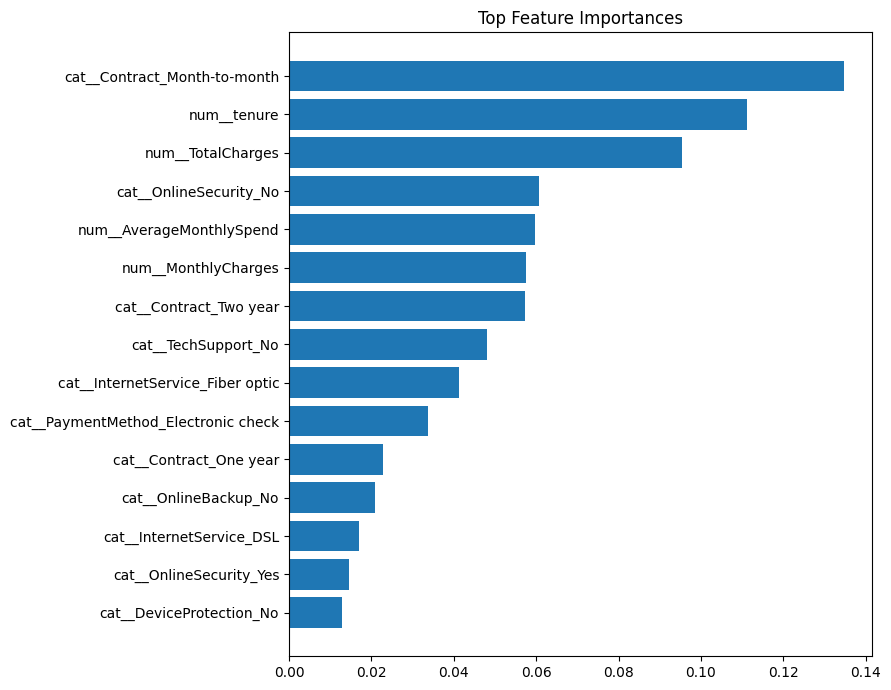

In [ ]:
top=importance.head(15).sort_values("importance")
plt.figure(figsize=(9,7)); plt.barh(top["feature"],top["importance"]); plt.title("Top Feature Importances"); plt.tight_layout(); plt.show()

## 22. SAVE PIPELINE

Save the entire fitted pipeline so the same preprocessing and model are used in the Streamlit application.

In [ ]:
from pathlib import Path
import joblib
path=Path("../models/churn_pipeline.joblib")
path.parent.mkdir(exist_ok=True)
joblib.dump(final_model,path)
print("Saved:",path.resolve())

Saved: /models/churn_pipeline.joblib


## Final note

This is an educational churn-risk system. A production system would additionally address threshold selection, probability calibration, fairness, privacy, monitoring, changing customer behavior, and the business cost of retention actions.